# TATE Confidence Bands

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == "notebooks" else cwd
if repo.name == "tcda_uq":
    sys.path.insert(0, str(repo.parent))
elif (repo / "tcda_uq").exists():
    sys.path.insert(0, str(repo))

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

This notebook builds TATE confidence bands on the tri-oracle
simulation harness and evaluates them against the known marginal
truth. It uses small CPU settings for a tutorial smoke run.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

from tcda_uq import evaluate_coverage, tate_band
from tcda_uq.datasets import TriOracleSimulation
from tcda_uq.estimators import cross_fit
from tcda_uq.metrics import interval_wise_error

In [3]:
sim = TriOracleSimulation(n_hom_dim=1, resolution=28, n_basis=5, noise_scale=0.3, seed=0)
sample = sim.sample(220, rng=1)
fit = cross_fit(
    sample.observed,
    sim.tseq,
    n_basis=5,
    n_splits=2,
    random_state=0,
    propensity_estimator=LogisticRegression(max_iter=500),
)
truth = sim.true_tate()[0]

In [4]:
specs = {
    "mbb": {"n_boot": 120, "rng": 2},
    "pv": {"n_boot": 120, "rng": 2},
    "lr": {"backend": "python"},
}

bands = {name: tate_band(fit, method=name, d=0, alpha=0.10, **kw) for name, kw in specs.items()}
rows = []
for name, band in bands.items():
    result = evaluate_coverage(band, truth)
    metric = interval_wise_error(band.lower, band.upper, truth) if name == "pv" else result.coverage
    rows.append(
        {
            "method": name,
            "reported_metric": "interval-wise error" if name == "pv" else "simultaneous coverage",
            "value": metric,
            "mean_width": band.mean_width(),
        }
    )
pd.DataFrame(rows)

,method,reported_metric,value,mean_width
0,mbb,simultaneous coverage,1.0,0.603531
1,pv,interval-wise error,0.0,0.454744
2,lr,simultaneous coverage,1.0,0.696334


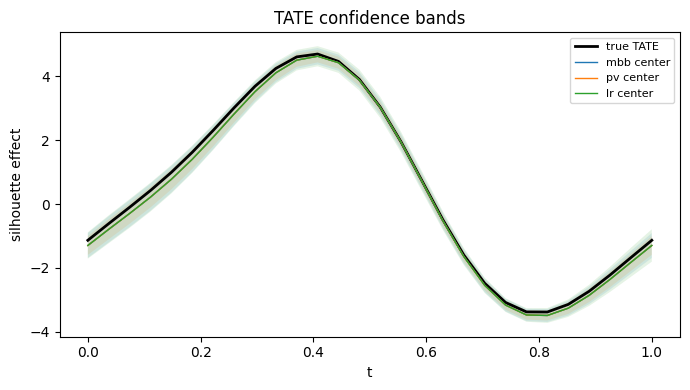

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sim.tseq, truth, color="black", lw=2, label="true TATE")
for name, band in bands.items():
    ax.plot(sim.tseq, band.center, lw=1, label=f"{name} center")
    ax.fill_between(sim.tseq, band.lower, band.upper, alpha=0.12)
ax.set(xlabel="t", ylabel="silhouette effect", title="TATE confidence bands")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()